В данном разделе будет выполнен подбор гиперпараметров модели **LGBMRegressor**
*   r^2 0.1712
*   rmse  2846
*   mae 1766,
т.к. на ней получены максимальный r^2 при дефолтовых настройках

Для поиска оптимальных гиперпараметров модели будет использовано 3 подхода:


*   **Grid Search** (Полный перебор) - задается сетка параметров тюнинга и перебираются все возможные комбинации
*   **Randomized Search** (Случайный поиск) - алгоритм случайно выбирает фиксированное число комбинаций из заданного для каждого гиперпараметра распределения
*   **Bayes Search** (Байесовская оптимизация) - Строит суррогатную модель (обычно Gaussian Process, TPE или Random Forest), которая предсказывает качество модели в любой точке пространства гиперпараметров.
Использует функцию приобретения (acquisition function: EI, UCB, PI и др.), чтобы выбрать следующую точку, балансируя exploration (исследование неизвестного) и exploitation (уточнение перспективных областей).
Обновляет модель после каждой итерации.



In [1]:
!pip install scikit-optimize

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 1.7 MB/s eta 0:00:00


In [2]:
#@title Импорт библиотек

import numpy as np
import pandas as pd
import sys
import seaborn as sns
import matplotlib.pyplot as plt

from lightgbm import LGBMRegressor
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import TargetEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (OrdinalEncoder, OneHotEncoder, StandardScaler,
                                   MinMaxScaler, TargetEncoder)
from imblearn.pipeline import Pipeline
from timeit import default_timer as timer
import random
from scipy.stats import randint as sp_randint
from scipy.stats import uniform as sp_uniform
from skopt.space import Integer, Real, Categorical
from skopt import BayesSearchCV
from sklearn.base import clone
from matplotlib.colors import LinearSegmentedColormap


# Для работы с Google Drive
# Для корректной работы с внешними .py файлов
from google.colab import drive

drive.mount('/content/drive')

# Путь к папке с .py файлами
sys.path.insert(0, '/content/drive/MyDrive/tools')
from helper import *
from plots import *

%matplotlib inline

Mounted at /content/drive


In [3]:
#@title Константы
SEED = 42

np.random.seed(SEED)
random.seed(SEED)

# **1. Общие преобразования**

In [7]:
# Загрузка данных
df = pd.read_csv('/content/drive/MyDrive/_Базы_/medical_insurance.csv')

In [8]:
# Общие преобразования
df_preprocessed = df.copy()

# Удаление 'person_id'
df_preprocessed.drop('person_id', axis=1, inplace=True)

In [9]:
# делим данные на признаки и таргет
X, y = divide_data(df_preprocessed, 'annual_medical_cost')
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=SEED)

In [11]:
del_feature = ['is_high_risk', 'household_size', 'dependents',
               'hospitalizations_last_3yrs', 'had_major_procedure', 'diastolic_bp',
               'systolic_bp', 'hba1c', 'proc_surgery_count']

numeric_cols = ['age', 'income',
                'bmi', 'visits_last_year',
                'days_hospitalized_last_3yrs', 'medication_count',
                'ldl',  # 'deductible', 'copay',
                # 'policy_term_years', 'policy_changes_last_2yrs',
                'provider_quality', 'risk_score',
                # 'annual_premium', 'monthly_premium', # удалены из датасета
                # 'claims_count',
                # 'avg_claim_amount', 'total_claims_paid', # удалены из датасета
                'chronic_count',
                'hypertension', 'diabetes', 'asthma', 'copd',
                'cardiovascular_disease', 'cancer_history', 'kidney_disease',
                'liver_disease', 'arthritis', 'mental_health',
                # 'proc_imaging_count', 'proc_physio_count',
                # 'proc_consult_count', 'proc_lab_count'
                ]

# признаки имеющие бинарные значения 0 или 1 и отражающие наличие/отсутствие заболевания
# не требуют каких-либо преобразований
is_disease_cols = ['hypertension', 'diabetes', 'asthma', 'copd',
                   'cardiovascular_disease', 'cancer_history', 'kidney_disease',
                   'liver_disease', 'arthritis', 'mental_health']

# Получаем датасет

# X_train
X_train = get_clear_df(X_train)

# Удалим высококоррелирующие признаки
del_feature = ['is_high_risk', 'household_size', 'dependents',
               'hospitalizations_last_3yrs', 'had_major_procedure', 'diastolic_bp',
               'systolic_bp', 'hba1c', 'proc_surgery_count',
               # Доп.удаление
               'deductible', 'copay', 'policy_term_years',
               'policy_changes_last_2yrs', 'claims_count', 'proc_imaging_count',
               'proc_physio_count', 'proc_consult_count', 'proc_lab_count']
X_train.drop(del_feature, axis=1, inplace=True)

# StandardScaler числовых фич с удалением исходных признаков
natural_columns = list(set(numeric_cols) - set(is_disease_cols))
scaled_columns = [f'{col}_ss'for col in natural_columns]
X_train[scaled_columns] = X_train[natural_columns]

# Введение 'bmi' ** 2
X_train['bmi_squared'] = X_train['bmi'] ** 2

In [12]:
# Новый препроцессор
preprocessor = create_preprocessor()
preprocessor['transformations'].transformers.append(
    ('scaler', StandardScaler(), scaled_columns)
)

# Включаем вывод в формате pandas
preprocessor.set_output(transform='pandas')

Стартовое кол-во числовых фич: 42
Итоговое кол-во числовых фич: 42


Pipeline(steps=[('nan_remover',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('most_frequent_cat',
                                                  SimpleImputer(strategy='most_frequent'),
                                                  ['alcohol_freq'])],
                                   verbose_feature_names_out=False)),
                ('transformations',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=Fa...
                                                                              'Gold',
                                                                              'Platinum']]),
                                                  ['urban_rural', 'education',
                                                   'marital_status',
                                                   'employment_status',
                                                   'plan_type',
                                                   'network_tier']),
                                                 ('scaler', StandardScaler(),
                                                  ['chronic_count_ss',
                                                   'days_hospitalized_last_3yrs_ss',
                                                   'bmi_ss', 'ldl_ss',
                                                   'risk_score_ss',
                                                   'provider_quality_ss',
                                                   'medication_count_ss',
                                                   'age_ss', 'income_ss',
                                                   'visits_last_year_ss'])],
                                   verbose_feature_names_out=False))])

In [13]:
base_model = ('LGBMRegressor', LGBMRegressor(random_state=SEED, max_depth=4,))

In [14]:
preprocessor.steps.append(base_model)
pipeline = preprocessor

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.018934 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2849
[LightGBM] [Info] Number of data points in the train set: 80000, number of used features: 47
[LightGBM] [Info] Start training from score 3004.867094
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

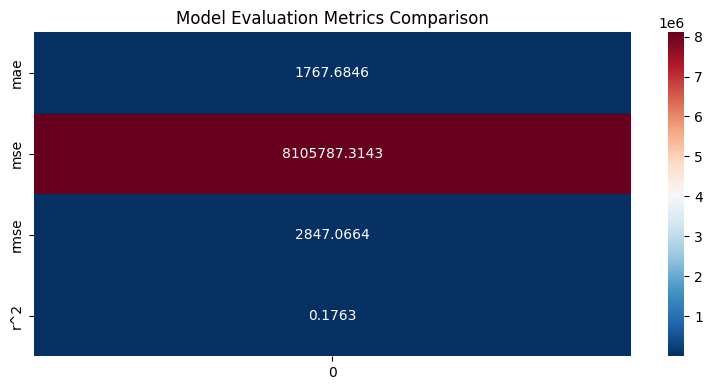

In [16]:
initial_metrics = evaluate_model(
    model=pipeline,
    model_name='LGBMRegressor',
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_true=y_test,
    seed=SEED
)

In [17]:
initial_metrics

,0
mae,1.767685e+03
mse,8.105787e+06
rmse,2.847066e+03
r^2,1.762535e-01


# **2.Подбор гиперпараметров**

In [81]:
#@title 2.1 Grid Search

# Новый препроцессор
preprocessor = create_preprocessor()
preprocessor['transformations'].transformers.append(
    ('scaler', StandardScaler(), scaled_columns)
)
base_model = ('LGBMRegressor', LGBMRegressor(random_state=SEED))
preprocessor.steps.append(base_model)
pipeline = preprocessor

param_grid = {
    # Сложность дерева
    'LGBMRegressor__num_leaves': [25, 50, 100],
    'LGBMRegressor__max_depth': [-1, 5, 10],  # -1 = без ограничений

    # Доля признаков, которые случайным образом выбираются для построения каждого дерева
    'LGBMRegressor__feature_fraction': [0.5, 0.8, 1.0],

    # Скорость обучения и количество деревьев
    # 'LGBMRegressor__learning_rate': [0.05, 0.15],
    # 'LGBMRegressor__n_estimators': [200, 800],

    # # Контроль переобучения (мин. объектов в листе)
    # 'LGBMRegressor__min_child_samples': [5, 20],

    # Стохастичность (субсэмплирование строк и признаков)
    # 'LGBMRegressor__subsample': [0.8, 1.0],
    # 'LGBMRegressor__colsample_bytree': [0.8, 1.0],

    # L1 / L2 регуляризация
    # 'LGBMRegressor__reg_alpha': [0.0, 0.5],
    # 'LGBMRegressor__reg_lambda': [0.0, 0.5],

    # Точность разбиений (бинирование)
    # 'LGBMRegressor__max_bin': [200, 255, 300]
}

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring='r2',
    cv=5,
    n_jobs=1,
    verbose=3
)

Стартовое кол-во числовых фич: 42
Итоговое кол-во числовых фич: 42


При запуске Grid Search в googleColabe выполнение подбора оптимальных параметров проходило 4.5 часа и процесс не заканчивался - данный метод выполняется полным перебором комбинаций всех указанных параметров. И обычно не дает лучший результат. Для сокращения времени выполнения оставлены только 3 параметра feature_fraction, num_leaves и max_depth

In [82]:
grid_search_start = timer()
grid_search.fit(X_train, y_train)
grid_search_end = timer()

Выходные данные были обрезаны до нескольких последних строк (5000).
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further 

In [83]:
print(f"Total time: {grid_search_end - grid_search_start:.2f} seconds")

Total time: 293.50 seconds


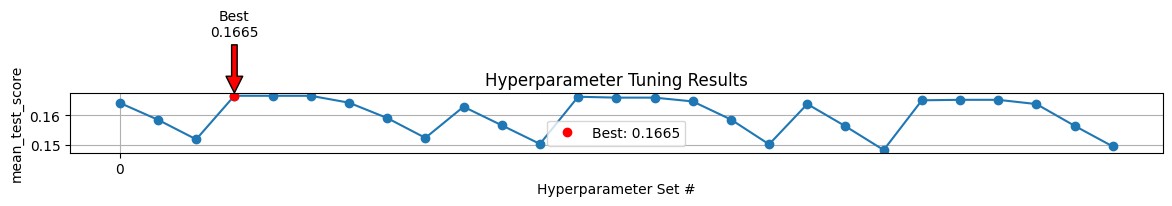

In [84]:
data = plot_hyperparam_search_results(grid_search.cv_results_, xtick_step=100)

In [85]:
grid_search.best_params_

{'LGBMRegressor__feature_fraction': 0.5,
 'LGBMRegressor__max_depth': 5,
 'LGBMRegressor__num_leaves': 25}

In [86]:
grid_search_best_model = grid_search.best_estimator_

[LightGBM] [Warning] feature_fraction is set=0.5, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.5
[LightGBM] [Warning] feature_fraction is set=0.5, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.5
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.015554 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2849
[LightGBM] [Info] Number of data points in the train set: 80000, number of used features: 47
[LightGBM] [Info] Start training from score 3004.867094
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with

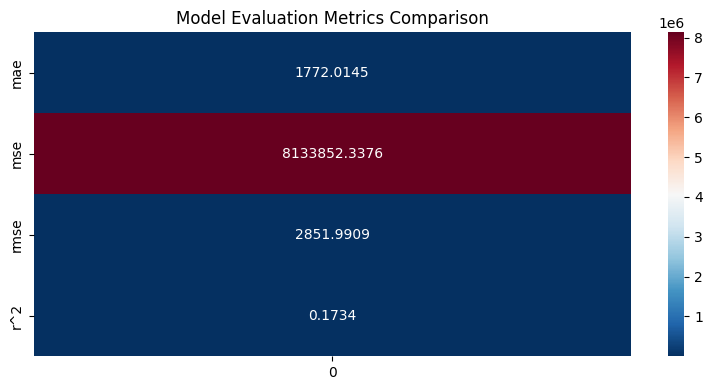

In [87]:
grid_search_metrics = evaluate_model(
    model=grid_search_best_model,
    model_name='LGBMRegressor',
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_true=y_test,
    seed=SEED
)

In [88]:
grid_search_metrics

,0
mae,1.772014e+03
mse,8.133852e+06
rmse,2.851991e+03
r^2,1.734015e-01


(<Figure size 800x400 with 2 Axes>,
                  0
 mae       4.329860
 mse   28065.023324
 rmse      4.924503
 r^2      -0.002852)

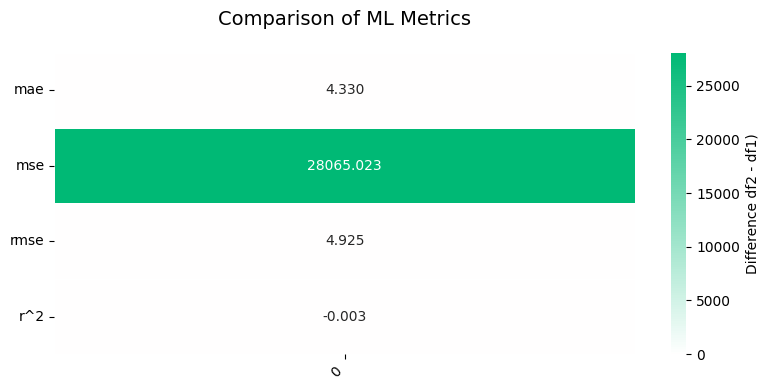

In [89]:
compare_metrics_heatmap(initial_metrics, grid_search_metrics)

Наивысший r2=17.34 получен при feature_fraction: 0.5, max_depth: 5, num_leaves: 50, и  позоляет незначительно лучшить показания на ошибках, и немного снижает r2

In [90]:
#@title 2.2 Randomized Search

param_dist = {
    "LGBMRegressor__num_leaves": sp_randint(5, 100),
    "LGBMRegressor__max_depth": sp_randint(-1, 10),
    "LGBMRegressor__min_child_samples": sp_randint(3, 10, 20),

    "LGBMRegressor__feature_fraction": sp_uniform(0.5, 1.0),

    "LGBMRegressor__learning_rate": sp_uniform(0.01, 0.15),
    "LGBMRegressor__n_estimators": sp_randint(10, 700),

    "LGBMRegressor__subsample": sp_uniform(0.6, 1.0),
    "LGBMRegressor__colsample_bytree": sp_uniform(0.6, 1.0),

    "LGBMRegressor__reg_alpha": sp_uniform(0.0, 0.5),
    "LGBMRegressor__reg_lambda": sp_uniform(0.0, 0.5)
}

In [91]:
randomized_search = RandomizedSearchCV(
    random_state=SEED,
    estimator=pipeline,
    param_distributions=param_dist,
    n_iter=100,
    scoring='r2',
    cv=5,
    n_jobs=1,
    verbose=3
)

In [92]:
randomized_search_start = timer()
randomized_search.fit(X_train, y_train)
randomized_search_end = timer()

Выходные данные были обрезаны до нескольких последних строк (5000).
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further 

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
365 fits failed out of a total of 500.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
75 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/imblearn/pipeline.py", line 522, in fit
    self._final_estimator.fit(Xt, yt, 

[LightGBM] [Warning] feature_fraction is set=0.7514424395117985, colsample_bytree=0.8050453285065249 will be ignored. Current value: feature_fraction=0.7514424395117985
[LightGBM] [Warning] feature_fraction is set=0.7514424395117985, colsample_bytree=0.8050453285065249 will be ignored. Current value: feature_fraction=0.7514424395117985
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.046223 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2849
[LightGBM] [Info] Number of data points in the train set: 80000, number of used features: 47
[LightGBM] [Info] Start training from score 3004.867094
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warni

In [93]:
print(f"Total time: {randomized_search_end - randomized_search_start:.2f} seconds")

Total time: 910.08 seconds


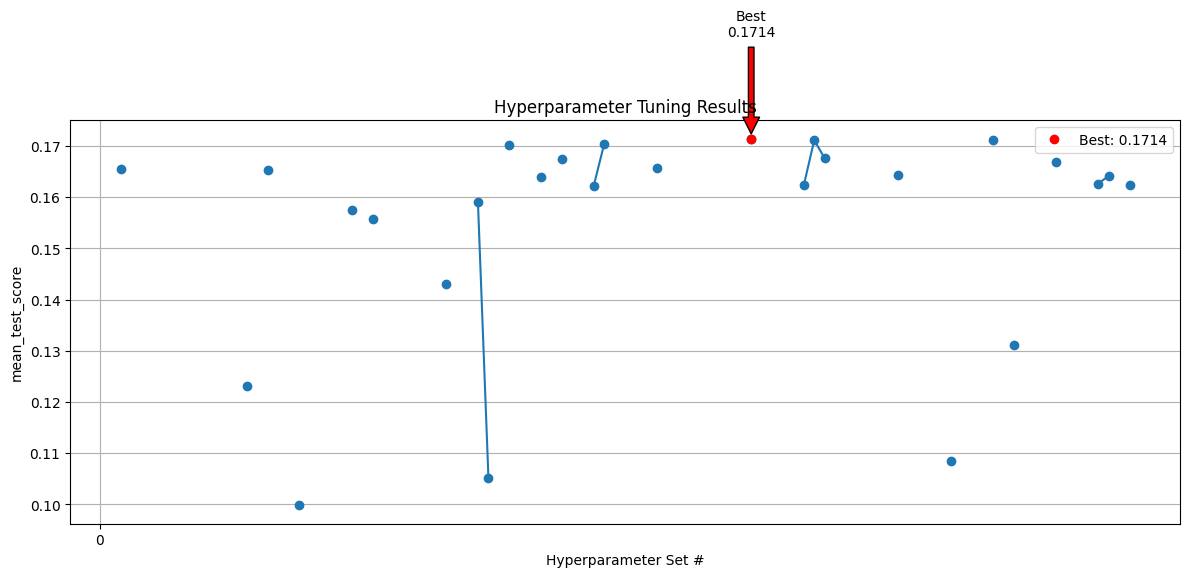

In [94]:
data = plot_hyperparam_search_results(randomized_search.cv_results_, xtick_step=100)

In [95]:
randomized_search.best_params_

{'LGBMRegressor__colsample_bytree': np.float64(0.8050453285065249),
 'LGBMRegressor__feature_fraction': np.float64(0.7514424395117985),
 'LGBMRegressor__learning_rate': np.float64(0.051209769553886314),
 'LGBMRegressor__max_depth': 2,
 'LGBMRegressor__min_child_samples': 28,
 'LGBMRegressor__n_estimators': 458,
 'LGBMRegressor__num_leaves': 36,
 'LGBMRegressor__reg_alpha': np.float64(0.02344823389560996),
 'LGBMRegressor__reg_lambda': np.float64(0.13433624101265368),
 'LGBMRegressor__subsample': np.float64(0.6221847420303016)}

[LightGBM] [Warning] feature_fraction is set=0.7514424395117985, colsample_bytree=0.8050453285065249 will be ignored. Current value: feature_fraction=0.7514424395117985
[LightGBM] [Warning] feature_fraction is set=0.7514424395117985, colsample_bytree=0.8050453285065249 will be ignored. Current value: feature_fraction=0.7514424395117985
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.046228 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2849
[LightGBM] [Info] Number of data points in the train set: 80000, number of used features: 47
[LightGBM] [Info] Start training from score 3004.867094
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warni

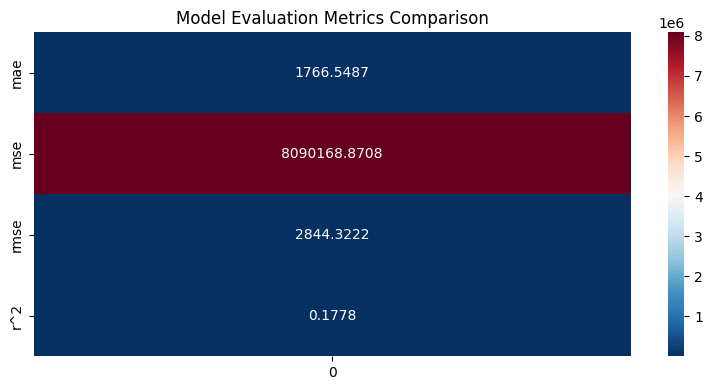

In [96]:
randomized_search_metrics = evaluate_model(
    model=randomized_search.best_estimator_,
    model_name='LGBMRegressor',
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_true=y_test,
    seed=SEED
)

In [97]:
randomized_search_metrics

,0
mae,1.766549e+03
mse,8.090169e+06
rmse,2.844322e+03
r^2,1.778408e-01


(<Figure size 800x400 with 2 Axes>,
                  0
 mae      -1.135888
 mse  -15618.443495
 rmse     -2.744224
 r^2       0.001587)

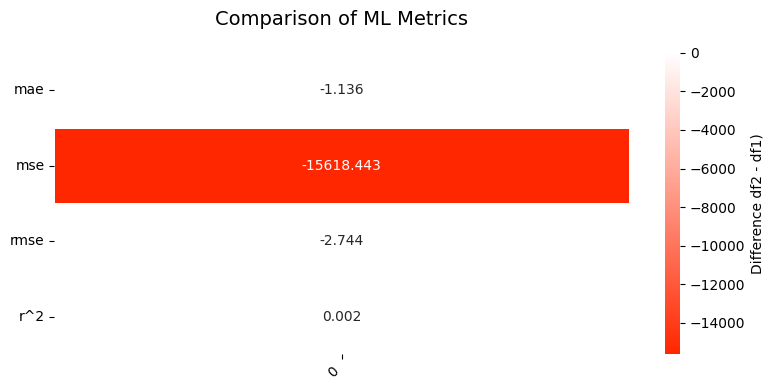

In [98]:
compare_metrics_heatmap(initial_metrics, randomized_search_metrics)

Алгоритм работы случайного поиска позволяет перебрать уже большее число параметров тюнинга за адекватное время, полученные лучшие параметры дают прирост метрик и r2

In [101]:
#@title 2.3 Bayes Search

param_bayes = {
    "LGBMRegressor__num_leaves": Integer(5, 100),
    "LGBMRegressor__max_depth": Integer(-1, 15),
    "LGBMRegressor__min_child_samples": Integer(5, 30),

    "LGBMRegressor__feature_fraction": Real(0.5, 1.0),

    # Логарифмическая шкала используется потому что:
    # 1) learning_rate обычно варьируется в порядках величины (0.001-0.1)
    # 2) Логарифмирование дает более равномерный поиск в широком диапазоне значений
    # 3) Разница между 0.01 и 0.02 часто значительнее, чем между 0.1 и 0.11
    "LGBMRegressor__learning_rate": Real(0.01, 0.15, prior='log-uniform'),

    "LGBMRegressor__n_estimators": Integer(10, 400),

    "LGBMRegressor__subsample": Real(0.8, 1.0),
    "LGBMRegressor__colsample_bytree": Real(0.8, 1.0),

    "LGBMRegressor__reg_alpha": Real(0.0, 0.5),
    "LGBMRegressor__reg_lambda": Real(0.0, 0.5)
}

In [102]:
bayes_search = BayesSearchCV(
    random_state=SEED,
    estimator=pipeline,
    search_spaces=param_bayes,
    n_iter=100,
    scoring='r2',
    optimizer_kwargs={'base_estimator': 'GP'},
    verbose=3,
    n_jobs=1
)

In [103]:
bayes_search_start = timer()
bayes_search.fit(X_train, y_train)
bayes_search_end = timer()

Выходные данные были обрезаны до нескольких последних строк (5000).
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further 

In [104]:
print(f"Total time: {bayes_search_end - bayes_search_start:.2f} seconds")

Total time: 2146.36 seconds


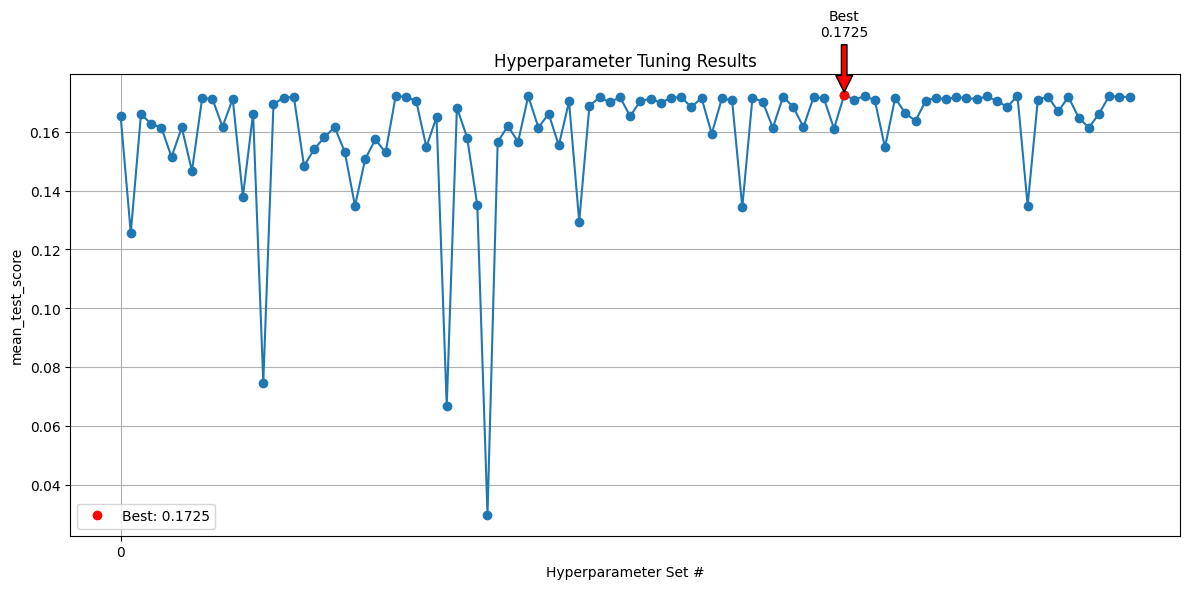

In [105]:
data = plot_hyperparam_search_results(bayes_search.cv_results_, xtick_step=100)

In [106]:
bayes_search.best_params_

OrderedDict([('LGBMRegressor__colsample_bytree', 1.0),
             ('LGBMRegressor__feature_fraction', 0.5),
             ('LGBMRegressor__learning_rate', 0.04789156143602583),
             ('LGBMRegressor__max_depth', 15),
             ('LGBMRegressor__min_child_samples', 30),
             ('LGBMRegressor__n_estimators', 342),
             ('LGBMRegressor__num_leaves', 5),
             ('LGBMRegressor__reg_alpha', 0.5),
             ('LGBMRegressor__reg_lambda', 0.5),
             ('LGBMRegressor__subsample', 0.8)])

[LightGBM] [Warning] feature_fraction is set=0.5, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.5
[LightGBM] [Warning] feature_fraction is set=0.5, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.5
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.016957 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2849
[LightGBM] [Info] Number of data points in the train set: 80000, number of used features: 47
[LightGBM] [Info] Start training from score 3004.867094
[LightGBM] [Warning] feature_fraction is set=0.5, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.5


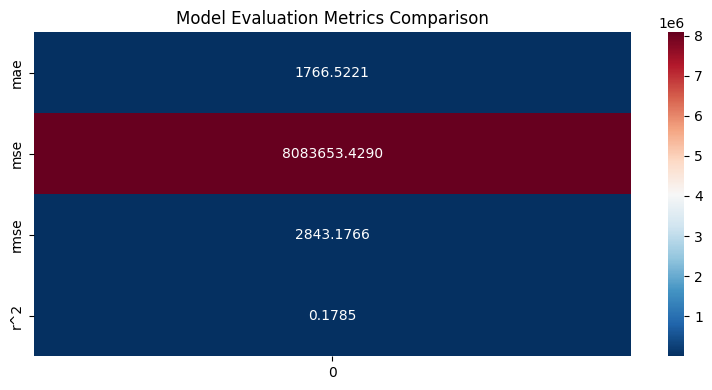

In [107]:
bayes_search_metrics = evaluate_model(
    model=bayes_search.best_estimator_,
    model_name='LGBMRegressor',
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_true=y_test,
    seed=SEED
)

In [108]:
bayes_search_metrics

,0
mae,1.766522e+03
mse,8.083653e+06
rmse,2.843177e+03
r^2,1.785029e-01


(<Figure size 800x400 with 2 Axes>,
                  0
 mae      -1.162512
 mse  -22133.885299
 rmse     -3.889796
 r^2       0.002249)

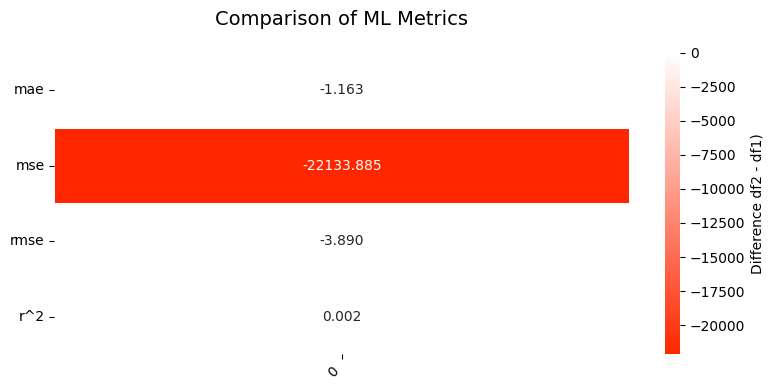

In [109]:
compare_metrics_heatmap(initial_metrics, bayes_search_metrics)

# **Выводы**

In [111]:
index=['Baseline', 'Grid Search', 'Randomized Search', 'Bayes Search']

columns=['MAE', 'MSE', 'RMSE', 'R^2', 'time']

bl = [1767, 8105787, 2847, 0.176, '-']  # Baseline

gs = [1772, 8133852, 2851, 0.1734, '293.50 seconds']  # Grid Search

rs = [1765, 8090169, 2844, 0.1778, '910.08 seconds']  # Randomized Search

bs = [1766, 8083653, 2831, 0.1785, '2146.36 seconds']  # Bayes Search

rows = [bl, gs,  rs, bs]

In [112]:
pd.DataFrame(rows, columns=columns, index=index)

,MAE,MSE,RMSE,R^2,time
Baseline,1767,8105787,2847,0.1760,-
Grid Search,1772,8133852,2851,0.1734,293.50 seconds
Randomized Search,1765,8090169,2844,0.1778,910.08 seconds
Bayes Search,1766,8083653,2831,0.1785,2146.36 seconds


In [ ]:
randomized_search.best_params_

{'LGBMRegressor__colsample_bytree': np.float64(0.8050453285065249),
 'LGBMRegressor__feature_fraction': np.float64(0.7514424395117985),
 'LGBMRegressor__learning_rate': np.float64(0.051209769553886314),
 'LGBMRegressor__max_depth': 2,
 'LGBMRegressor__min_child_samples': 28,
 'LGBMRegressor__n_estimators': 458,
 'LGBMRegressor__num_leaves': 36,
 'LGBMRegressor__reg_alpha': np.float64(0.02344823389560996),
 'LGBMRegressor__reg_lambda': np.float64(0.13433624101265368),
 'LGBMRegressor__subsample': np.float64(0.6221847420303016)}

In [ ]:
bayes_search.best_params_

OrderedDict([('LGBMRegressor__colsample_bytree', 1.0),
             ('LGBMRegressor__feature_fraction', 0.5),
             ('LGBMRegressor__learning_rate', 0.04789156143602583),
             ('LGBMRegressor__max_depth', 15),
             ('LGBMRegressor__min_child_samples', 30),
             ('LGBMRegressor__n_estimators', 342),
             ('LGBMRegressor__num_leaves', 5),
             ('LGBMRegressor__reg_alpha', 0.5),
             ('LGBMRegressor__reg_lambda', 0.5),
             ('LGBMRegressor__subsample', 0.8)])

Bayes Search подход подбора гиперпараметров модели градиентного бустинга LGBM дал самый хороший результат
*   r^2 0.1785
*   rmse  2831
*   mae 1766

Как видим все подходы вели к большому кол-ву деревьев 350-450, lr - около 0.05, и сокращению доли используемых параметров при построении деревьев в ансамбле. Глубина сильно варьируется - не проследить явной закономерности

В результате подбора гиперпараметров показатели качества базовой модели улучшены на несколько единиц, а прирост r2 составил 0.0015

По результатам проделанных преобразований можно сделать вывод, что имеющихся признаков (после исключения бизнесово-ошибочных, дублирующих), хватит, чтобы построить модель с высокими метриками качества для низких значений таргета до 10К - это мы видели на графиках y_pred-y_true.
Повысить качество предикта на всем диапазоне таргета не получилось даже при логарифмировании у, эффект гетероскедастичность не нивелирован.